In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt



In [ ]:
from google.colab import files
files.upload()


In [ ]:
df = pd.read_csv("/content/vmCloud_data.csv", engine='python', on_bad_lines='skip')
df.head()

,vm_id,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status
0,c5215826-6237-4a33-9312-72c1df909881,2023-01-25 09:10:54,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,network,medium,waiting
1,29690bc6-1f34-403b-b509-a1ecb1834fb8,2023-01-26 04:46:34,71.518937,29.901883,NaN,362.273569,5348.0,41.396040,0.349856,io,high,completed
2,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,2023-01-13 23:39:47,NaN,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,io,medium,completed
3,e672e32f-c134-4fbc-992b-34eb63bef6bf,2023-02-09 11:45:49,54.488318,88.100960,NaN,195.639954,5876.0,16.456670,0.529511,compute,high,completed
4,f38b8b50-6926-4533-be4f-89ad11624071,2023-06-14 08:27:26,42.365480,NaN,NaN,359.451537,3361.0,55.307992,0.351907,NaN,medium,waiting


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 12 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   vm_id                      object 
 1   timestamp                  object 
 2   cpu_usage                  float64
 3   memory_usage               float64
 4   network_traffic            float64
 5   power_consumption          float64
 6   num_executed_instructions  float64
 7   execution_time             float64
 8   energy_efficiency          float64
 9   task_type                  object 
 10  task_priority              object 
 11  task_status                object 
dtypes: float64(7), object(5)
memory usage: 183.1+ MB


In [ ]:
df.shape
df.isnull().sum()


,0
vm_id,200638
timestamp,200666
cpu_usage,199038
memory_usage,200510
network_traffic,199481
power_consumption,200271
num_executed_instructions,199686
execution_time,199827
energy_efficiency,200042
task_type,199962


In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["timestamp"] = df["timestamp"].astype("int64") // 10**9
df.drop(columns=["vm_id"], inplace=True)

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
df[categorical_cols] = df[categorical_cols].fillna("Unknown")


In [ ]:
print(df.isnull().sum())


timestamp                    0
cpu_usage                    0
memory_usage                 0
network_traffic              0
power_consumption            0
num_executed_instructions    0
execution_time               0
energy_efficiency            0
task_type                    0
task_priority                0
task_status                  0
dtype: int64


In [ ]:
df.to_csv("vmCloud_final_cleaned.csv", index=False)
print("Final dataset saved successfully")

Final dataset saved successfully


In [ ]:
print(df.head())

    timestamp  cpu_usage  memory_usage  network_traffic  power_consumption  \
0  1674637854  54.881350     78.950861       164.775973         287.808986   
1  1674708394  71.518937     29.901883       500.007572         362.273569   
2  1673653187  50.012232     92.709195       203.674847         231.467903   
3  1675943149  54.488318     88.100960       500.007572         195.639954   
4  1686731246  42.365480     49.981898       500.007572         359.451537   

   num_executed_instructions  execution_time  energy_efficiency task_type  \
0                     7527.0       69.345575           0.553589   network   
1                     5348.0       41.396040           0.349856        io   
2                     5483.0       24.602549           0.796277        io   
3                     5876.0       16.456670           0.529511   compute   
4                     3361.0       55.307992           0.351907   Unknown   

  task_priority task_status  
0        medium     waiting  
1       

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
print("Numeric columns that will be checked for outliers:")
print(numeric_cols)

Numeric columns that will be checked for outliers:
Index(['timestamp', 'cpu_usage', 'memory_usage', 'network_traffic',
       'power_consumption', 'num_executed_instructions', 'execution_time',
       'energy_efficiency'],
      dtype='object')


In [ ]:
df.drop(columns=["task_type", "task_priority", "task_status"], inplace=True)
numeric_cols = df.select_dtypes(include=np.number).columns

In [ ]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {outliers.shape[0]} outliers remaining")


timestamp: 200666 outliers remaining
cpu_usage: 0 outliers remaining
memory_usage: 0 outliers remaining
network_traffic: 0 outliers remaining
power_consumption: 0 outliers remaining
num_executed_instructions: 0 outliers remaining
execution_time: 0 outliers remaining
energy_efficiency: 0 outliers remaining


In [ ]:
def remove_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df


In [ ]:
df = remove_outliers_iqr(df, numeric_cols)
print("Final dataset shape:", df.shape)


Final dataset shape: (1799334, 8)


In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [ ]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.6, min_samples=5)
df["DBSCAN_Cluster"] = dbscan.fit_predict(df[numeric_cols])
print("DBSCAN Cluster Counts:")
print(df["DBSCAN_Cluster"].value_counts())

DBSCAN Cluster Counts:
DBSCAN_Cluster
 0    1798405
-1        927
 1          2
Name: count, dtype: int64


In [ ]:
wcss = []
for k in range(1, 8):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(df[numeric_cols])
  wcss.append(kmeans.inertia_)

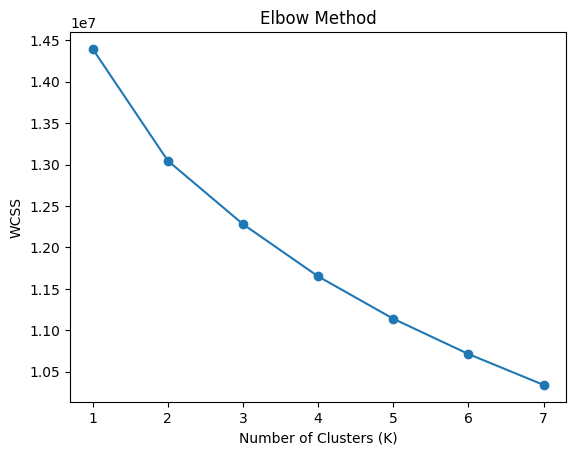

In [ ]:
plt.plot(range(1, 8), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df[numeric_cols])

df["Cluster"] = clusters


In [ ]:
df["Cluster"].value_counts()

,count
Cluster,
0,692971
2,555104
1,551259


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df[numeric_cols])

df["PCA1"] = pca_data[:, 0]
df["PCA2"] = pca_data[:, 1]

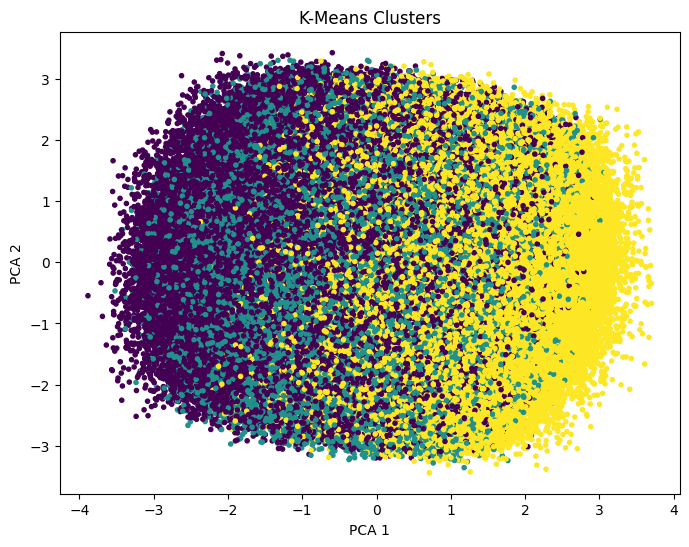

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df["PCA1"], df["PCA2"], c=df["Cluster"], cmap='viridis',s=9)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters")
plt.show()

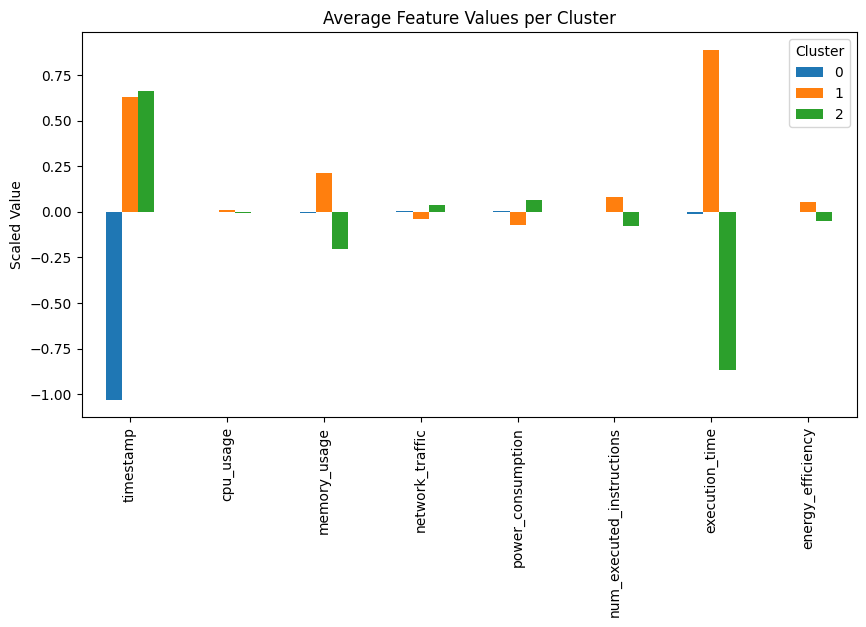

In [ ]:

cluster_means = df.groupby("Cluster")[numeric_cols].mean()

cluster_means.T.plot(kind="bar", figsize=(10,5))
plt.title("Average Feature Values per Cluster")
plt.ylabel("Scaled Value")
plt.show()

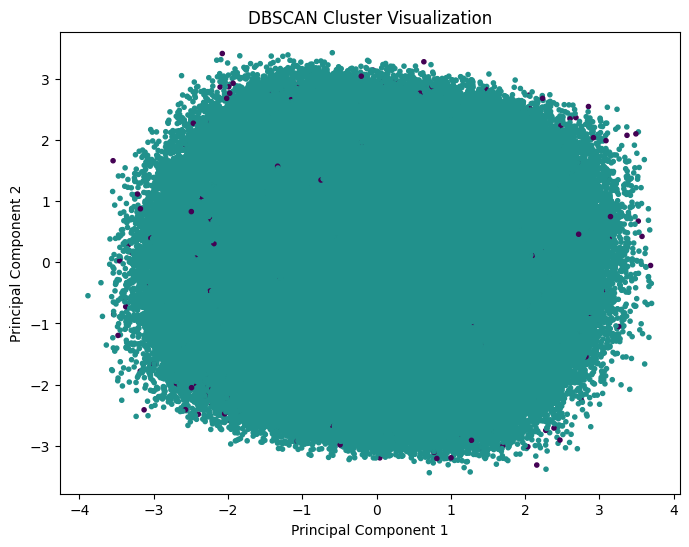

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1],
            c=df["DBSCAN_Cluster"], cmap='viridis', s=9)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Cluster Visualization")
plt.show()

In [ ]:
kmeans2 = KMeans(n_clusters=2, random_state=42)
clusters2 = kmeans2.fit_predict(df[numeric_cols])

df["Cluster2"] = clusters2


In [ ]:
df["Cluster2"].value_counts()

,count
Cluster2,
1,900216
0,899118


In [ ]:
from sklearn.decomposition import PCA

pca2 = PCA(n_components=2)
pca_data2 = pca.fit_transform(df[numeric_cols])

df["PCA1"] = pca_data2[:, 0]
df["PCA2"] = pca_data2[:, 1]

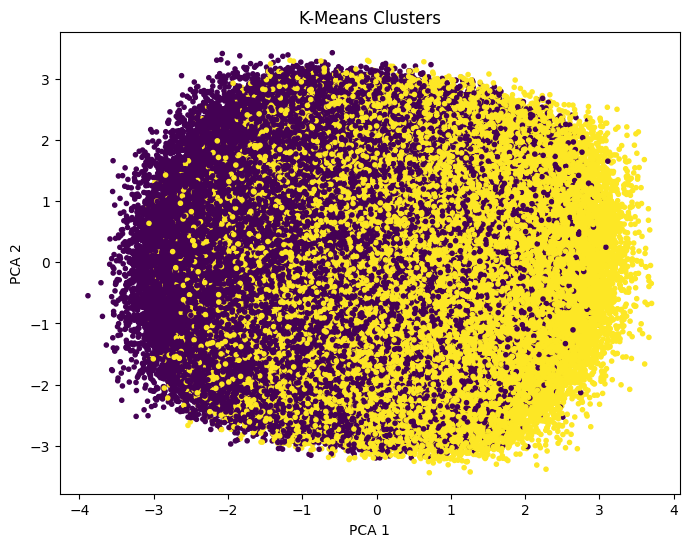

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df["PCA1"], df["PCA2"], c=df["Cluster2"], cmap='viridis',s=9)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters")
plt.show()

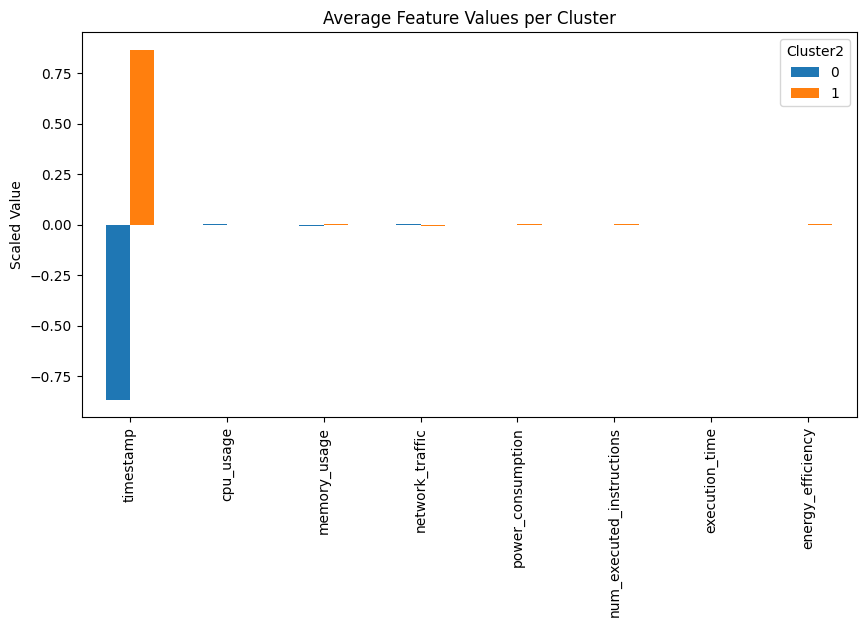

In [ ]:

cluster_means2 = df.groupby("Cluster2")[numeric_cols].mean()

cluster_means2.T.plot(kind="bar", figsize=(10,5))
plt.title("Average Feature Values per Cluster")
plt.ylabel("Scaled Value")
plt.show()